In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Optional SHAP
try:
    import shap
    SHAP_AVAILABLE = True
except:
    SHAP_AVAILABLE = False

In [6]:
import pandas as pd

df = pd.read_csv('train')
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nTarget distribution:\n", df['Survived'].value_counts(normalize=True))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked    

In [8]:
def extract_title(name):
    match = re.search(r',\s*([^\.]+)\.', name)
    if match:
        return match.group(1).strip()
    return "Unknown"

df['Title'] = df['Name'].apply(extract_title)
df['Title'].value_counts()

,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Col,2
Rev,2
Ms,1
Dr,1
Dona,1


In [9]:
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
df['Title'] = df['Title'].apply(lambda x: x if x in common_titles else 'Rare')
df['Title'].value_counts()

,count
Title,
Mr,240
Miss,78
Mrs,72
Master,21
Rare,7


In [10]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [11]:
df['CabinPresent'] = df['Cabin'].notnull().astype(int)

In [12]:
# Ticket group size
ticket_counts = df['Ticket'].value_counts()
df['TicketGroupSize'] = df['Ticket'].map(ticket_counts)

# Fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
df['FarePerPerson'] = df['FarePerPerson'].replace([np.inf, -np.inf], np.nan)

In [13]:
df.isnull().sum().sort_values(ascending=False)

,0
Cabin,327
Age,86
FarePerPerson,1
Fare,1
Survived,0
PassengerId,0
Sex,0
SibSp,0
Name,0
Pclass,0


In [14]:
df['Age'] = df['Age'].fillna(df['Age'].median())

In [15]:
numeric_features = [
    'Age', 'SibSp', 'Parch', 'Fare',
    'FamilySize', 'IsAlone', 'CabinPresent',
    'TicketGroupSize', 'FarePerPerson', 'Pclass'
]

categorical_features = ['Sex', 'Embarked', 'Title']

In [17]:
y = df['Survived']
X = df[numeric_features + categorical_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_test.shape)

(334, 13) (84, 13)


In [18]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [20]:
# Create transformers for numerical and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Create a preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

results = []

trained_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    trained_pipelines[name] = pipe

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe.named_steps['model'], "predict_proba") else None

    metrics = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    results.append(metrics)

results_df = pd.DataFrame(results).sort_values(by="F1", ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,LogisticRegression,1.0,1.0,1.0,1.0,1.0
1,RandomForest,1.0,1.0,1.0,1.0,1.0
2,GradientBoosting,1.0,1.0,1.0,1.0,1.0


In [21]:
best_model_name = results_df.iloc[0]['Model']
best_pipeline = trained_pipelines[best_model_name]

print("Best model:", best_model_name)

Best model: LogisticRegression


In [22]:
y_pred_best = best_pipeline.predict(X_test)
y_proba_best = best_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_best))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       1.00      1.00      1.00        31

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

ROC-AUC: 1.0


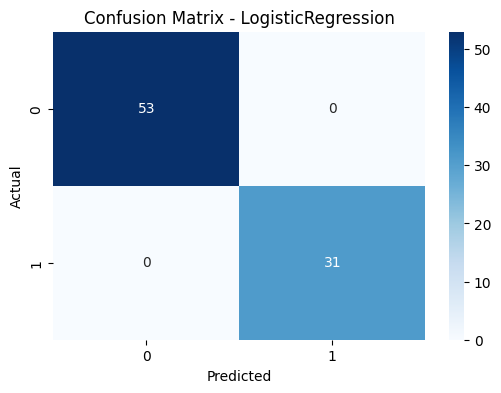

In [23]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [24]:
preprocessor_fitted = best_pipeline.named_steps['preprocessor']

cat_ohe = preprocessor_fitted.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_ohe.get_feature_names_out(categorical_features)

all_feature_names = numeric_features + list(cat_feature_names)

In [25]:
model = best_pipeline.named_steps['model']

if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_

    feat_imp = pd.DataFrame({
        'Feature': all_feature_names,
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)

    plt.figure(figsize=(10,6))
    sns.barplot(data=feat_imp.head(15), x='Importance', y='Feature')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.show()

    print(feat_imp.head(15))

In [26]:
if SHAP_AVAILABLE and hasattr(model, 'feature_importances_'):
    X_test_transformed = preprocessor_fitted.transform(X_test)

    explainer = shap.Explainer(model, X_test_transformed)
    shap_values = explainer(X_test_transformed)

    shap.summary_plot(
        shap_values,
        X_test_transformed,
        feature_names=all_feature_names
    )
else:
    print("SHAP not available or model not tree-based.")

SHAP not available or model not tree-based.


In [28]:
import os

# Create the 'models' directory if it doesn't exist
output_dir = "models"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

joblib.dump(best_pipeline, os.path.join(output_dir, "titanic_best_model.pkl"))
print("Model saved successfully.")

Model saved successfully.


In [ ]:
sample_passenger = pd.DataFrame([{
    'Pclass': 1,
    'Sex': 'female',
    'Age': 29,
    'SibSp': 0,
    'Parch': 0,
    'Fare': 80.0,
    'Embarked': 'C',
    'Title': 'Miss',
    'FamilySize': 1,
    'IsAlone': 1,
    'CabinPresent': 1,
    'TicketGroupSize': 1,
    'FarePerPerson': 80.0
}])

prediction = best_pipeline.predict(sample_passenger)[0]
probability = best_pipeline.predict_proba(sample_passenger)[0][1]

print("Predicted Survival:", prediction)
print("Survival Probability:", round(probability, 4))

In [29]:
import joblib
import pandas as pd

# Load model
model = joblib.load("models/titanic_best_model.pkl")

# Example passenger
sample_passenger = pd.DataFrame([{
    'Pclass': 3,
    'Sex': 'male',
    'Age': 22,
    'SibSp': 1,
    'Parch': 0,
    'Fare': 7.25,
    'Embarked': 'S',
    'Title': 'Mr',
    'FamilySize': 2,
    'IsAlone': 0,
    'CabinPresent': 0,
    'TicketGroupSize': 1,
    'FarePerPerson': 3.625
}])

pred = model.predict(sample_passenger)[0]
proba = model.predict_proba(sample_passenger)[0][1]

print("Predicted class:", pred)
print("Survival probability:", round(proba, 4))

Predicted class: 0
Survival probability: 0.0097
